In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats as st
import math as mth
import seaborn as sns
from datetime import datetime

hypo = pd.read_csv("/datasets/hypotheses_us.csv", sep = ";")
print(hypo.head(10))

                                          Hypothesis  Reach  Impact  \
0  Add two new channels for attracting traffic. T...      3      10   
1  Launch your own delivery service. This will sh...      2       5   
2  Add product recommendation blocks to the store...      8       3   
3  Change the category structure. This will incre...      8       3   
4  Change the background color on the main page. ...      3       1   
5  Add a customer review page. This will increase...      3       2   
6  Show banners with current offers and sales on ...      5       3   
7  Add a subscription form to all the main pages....     10       7   
8  Launch a promotion that gives users discounts ...      1       9   

   Confidence  Effort  
0           8       6  
1           4      10  
2           7       3  
3           3       8  
4           1       1  
5           2       3  
6           8       3  
7           8       5  
8           9       5  


# Priorización de Hipótesis

### Método ICE

In [3]:
# ICE = (Impacto*Confianza) / Esfuerzo
hypo["ice"] = (hypo["Impact"]*hypo["Confidence"])/hypo["Effort"]
print(hypo[["Hypothesis","ice"]].sort_values(by= "ice", ascending = False))

                                          Hypothesis        ice
8  Launch a promotion that gives users discounts ...  16.200000
0  Add two new channels for attracting traffic. T...  13.333333
7  Add a subscription form to all the main pages....  11.200000
6  Show banners with current offers and sales on ...   8.000000
2  Add product recommendation blocks to the store...   7.000000
1  Launch your own delivery service. This will sh...   2.000000
5  Add a customer review page. This will increase...   1.333333
3  Change the category structure. This will incre...   1.125000
4  Change the background color on the main page. ...   1.000000


### Método RICE

In [4]:
# RICE = (Alcance*Impacto*Confianza) / Esfuerzo
hypo["rice"] = (hypo["Impact"]*hypo["Confidence"]*hypo["Reach"])/hypo["Effort"]
print(hypo[["Hypothesis","rice"]].sort_values(by= "rice", ascending = False))

                                          Hypothesis   rice
7  Add a subscription form to all the main pages....  112.0
2  Add product recommendation blocks to the store...   56.0
0  Add two new channels for attracting traffic. T...   40.0
6  Show banners with current offers and sales on ...   40.0
8  Launch a promotion that gives users discounts ...   16.2
3  Change the category structure. This will incre...    9.0
1  Launch your own delivery service. This will sh...    4.0
5  Add a customer review page. This will increase...    4.0
4  Change the background color on the main page. ...    3.0


In [5]:
print(hypo[["Hypothesis", "ice", "rice"]].sort_values(by="rice", ascending = False))

                                          Hypothesis        ice   rice
7  Add a subscription form to all the main pages....  11.200000  112.0
2  Add product recommendation blocks to the store...   7.000000   56.0
0  Add two new channels for attracting traffic. T...  13.333333   40.0
6  Show banners with current offers and sales on ...   8.000000   40.0
8  Launch a promotion that gives users discounts ...  16.200000   16.2
3  Change the category structure. This will incre...   1.125000    9.0
1  Launch your own delivery service. This will sh...   2.000000    4.0
5  Add a customer review page. This will increase...   1.333333    4.0
4  Change the background color on the main page. ...   1.000000    3.0


### Conclusión:
La escala es mayor en RICE, así mismo su valor siempre es mayor que ice. Ambas métricas priorizan las hipótesis 7, 2, 0, 6 y 8 entre los primeros lugares.

# Análisis del test AB

In [6]:
orders = pd.read_csv("/datasets/orders_us.csv")
visits = pd.read_csv("/datasets/visits_us.csv")
print(orders.head(10))
print(visits.head(10))

   transactionId   visitorId        date  revenue group
0     3667963787  3312258926  2019-08-15     30.4     B
1     2804400009  3642806036  2019-08-15     15.2     B
2     2961555356  4069496402  2019-08-15     10.2     A
3     3797467345  1196621759  2019-08-15    155.1     B
4     2282983706  2322279887  2019-08-15     40.5     B
5      182168103   935554773  2019-08-15     35.0     B
6      398296753  2900797465  2019-08-15     30.6     B
7     2626614568    78758296  2019-08-15     20.1     A
8     1576988021   295230930  2019-08-15    215.9     A
9     1506739906  1882260405  2019-08-15     30.5     B
         date group  visits
0  2019-08-01     A     719
1  2019-08-02     A     619
2  2019-08-03     A     507
3  2019-08-04     A     717
4  2019-08-05     A     756
5  2019-08-06     A     667
6  2019-08-07     A     644
7  2019-08-08     A     610
8  2019-08-09     A     617
9  2019-08-10     A     406


### 1. Representación gráfica sobre el ingreso acumulado de los grupos

In [28]:
# crea una matriz con valores únicos de parejas fecha-grupo
datesGroups = orders[['date','group']].drop_duplicates()
ordersAggregated = datesGroups.apply(lambda x: orders[np.logical_and(orders['date'] <= x['date'], orders['group'] == x['group'])].agg({'date' : 'max', 'group' : 'max', 'transactionId' : pd.Series.nunique, 'visitorId' : pd.Series.nunique, 'revenue' : 'sum'}), axis=1).sort_values(by=['date','group'])
visitsAggregated = datesGroups.apply(lambda x: visits[np.logical_and(visits['date'] <= x['date'], visits['group'] == x['group'])].agg({'date' : 'max', 'group' : 'max', 'visits' : 'sum'}), axis=1).sort_values(by=['date','group'])
ordersAggregated.info()
visitsAggregated.info()
cumulativeData = ordersAggregated.merge(visitsAggregated, left_on=['date', 'group'], right_on=['date', 'group'])
cumulativeData.info()
cumulativeData.columns = ['date', 'group', 'orders', 'buyers', 'revenue', 'visitors']
print(cumulativeData.head(5))

<class 'pandas.core.frame.DataFrame'>
Int64Index: 62 entries, 55 to 930
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           62 non-null     object 
 1   group          62 non-null     object 
 2   transactionId  62 non-null     int64  
 3   visitorId      62 non-null     int64  
 4   revenue        62 non-null     float64
dtypes: float64(1), int64(2), object(2)
memory usage: 2.9+ KB
<class 'pandas.core.frame.DataFrame'>
Int64Index: 62 entries, 55 to 930
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   date    62 non-null     object
 1   group   62 non-null     object
 2   visits  62 non-null     int64 
dtypes: int64(1), object(2)
memory usage: 1.9+ KB
<class 'pandas.core.frame.DataFrame'>
Int64Index: 62 entries, 0 to 61
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0

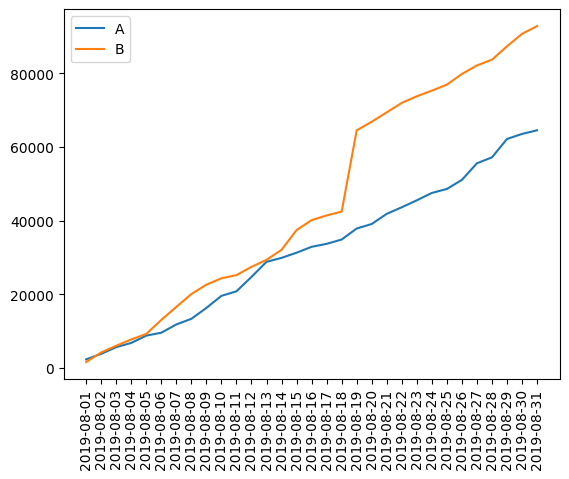

In [29]:
### Gráfica ingresos acumulados  
# DataFrame con pedidos acumulados e ingresos acumulados por día, grupo A
cumulativeRevenueA = cumulativeData[cumulativeData['group']=='A'][['date','revenue', 'orders']]
# DataFrame con pedidos acumulados e ingresos acumulados por día, grupo B
cumulativeRevenueB = cumulativeData[cumulativeData['group']=='B'][['date','revenue', 'orders']]
# Trazar el gráfico de ingresos del grupo A
plt.plot(cumulativeRevenueA['date'], cumulativeRevenueA['revenue'], label='A')
# Trazar el gráfico de ingresos del grupo B
plt.plot(cumulativeRevenueB['date'], cumulativeRevenueB['revenue'], label='B')
plt.xticks(rotation=90)
plt.legend()

### Comentario: 
Este gráfico nos muestra que ambos grupos presentan un tamaño de compra muy similar a lo largo del tiempo. Sin embargo, a partir del 19 de agosto, los ingresos del grupo B aumentaron. Esto debe estar justificado por un valor atípico que se presentó ese día en el grupo B.

### 2. Representación gráfica del tamaño promedio de la compra acumulado

<class 'pandas.core.frame.DataFrame'>
Int64Index: 31 entries, 0 to 60
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   date     31 non-null     object 
 1   revenue  31 non-null     float64
 2   orders   31 non-null     int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 992.0+ bytes


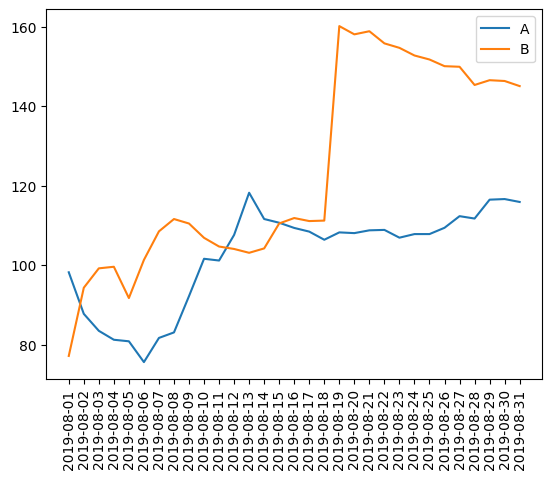

In [30]:
plt.plot(cumulativeRevenueA['date'], cumulativeRevenueA['revenue']/cumulativeRevenueA['orders'], label='A')
plt.plot(cumulativeRevenueB['date'], cumulativeRevenueB['revenue']/cumulativeRevenueB['orders'], label='B')
plt.xticks(rotation=90)
plt.legend()
cumulativeRevenueA.info()

### Comentario:
Similar al grafico anterior, el ticket de ambos grupos presenta un crecimiento parecido (dentro del mismo rango). Sin embargo, el 19 de agosto el ticket del B asciende repentinamente (debido a un usuario que tuvo una compra atipica). Luego de esto, decrece pero manteniéndose superior al grupo A. El experimento podría desarrollarse durante más tiempo hasta poder observar la tendencia definitiva y clara.

### 3. Representa gráficamente la diferencia relativa en el tamaño de pedido promedio acumulado para el grupo B en comparación con el grupo A

In [31]:
cumulativeRevenueB['date'] = pd.to_datetime(cumulativeRevenueB['date'])
cumulativeRevenueA['date'] = pd.to_datetime(cumulativeRevenueA['date'])
print(cumulativeRevenueB.head(5))
print(cumulativeRevenueA.head(5))

        date  revenue  orders
1 2019-08-01   1620.0      21
3 2019-08-02   4243.8      45
5 2019-08-03   6050.6      61
7 2019-08-04   7767.9      78
9 2019-08-05   9262.9     101
        date  revenue  orders
0 2019-08-01   2356.8      24
2 2019-08-02   3860.3      44
4 2019-08-03   5675.5      68
6 2019-08-04   6822.1      84
8 2019-08-05   8810.2     109


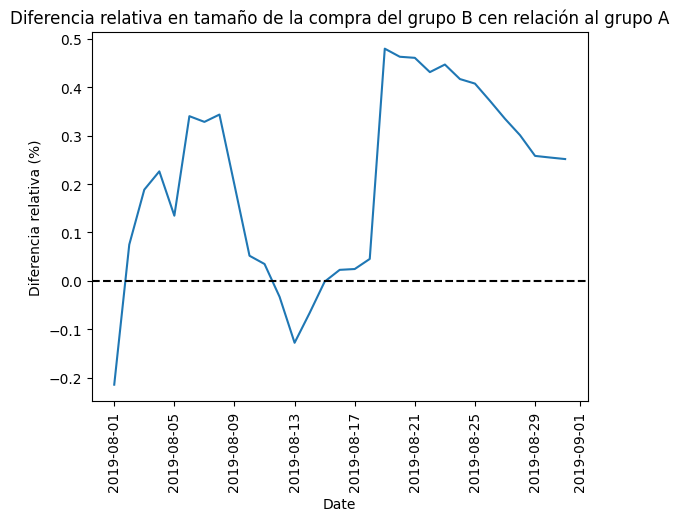

In [32]:
# Graficaos diferencia relativa con grupo B como numerador
cumulativeRevenueA = cumulativeRevenueA.reset_index(drop=True)
cumulativeRevenueB = cumulativeRevenueB.reset_index(drop=True)
plt.plot(cumulativeRevenueB['date'], ((cumulativeRevenueB['revenue']/cumulativeRevenueB['orders'])/(cumulativeRevenueA['revenue']/cumulativeRevenueA['orders']))-1)
plt.axhline(y=0, color='black', linestyle='--')
plt.title("Diferencia relativa en tamaño de la compra del grupo B cen relación al grupo A")
plt.xlabel("Date")
plt.ylabel("Diferencia relativa (%)")
plt.xticks(rotation=90)
plt.show()

### Comentario:
Mediante la gráfica corroboramos que no hay una tendencia clara o continua. Por lo general el grupo B presenta mayores tamaños de compra pero hubo 2 momentos en que el grupo A fue mayor. Así mismo vemos que el 19 de agosto, el grupo B tuvo casi un 5% de ingresos por encima del grupo A. Luego la diferencia entre los grupos disminuyó.

### 4. Tasa de conversion para cada grupo y representación gráfica

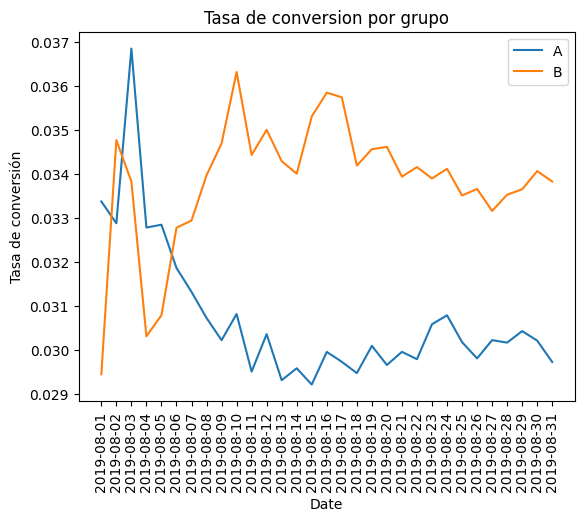

In [33]:
# proceso del sprint:
# calcular la conversión acumulada
cumulativeData['conversion'] = cumulativeData['orders']/cumulativeData['visitors']

# seleccionar datos en el grupo A
cumulativeDataA = cumulativeData[cumulativeData['group']=='A']

# seleccionar datos en el grupo B
cumulativeDataB = cumulativeData[cumulativeData['group']=='B']
cumulativeDataA = cumulativeDataA.reset_index(drop=True)
cumulativeDataB = cumulativeDataB.reset_index(drop=True)
# trazar los gráficos
plt.plot(cumulativeDataA['date'], cumulativeDataA['conversion'], label='A')
plt.plot(cumulativeDataB['date'], cumulativeDataB['conversion'], label='B')
plt.title("Tasa de conversion por grupo")
plt.xlabel("Date")
plt.ylabel("Tasa de conversión")
plt.xticks(rotation=90)
plt.legend()
plt.show()


### Comentario:
Con los datos que tenemos aún no vemos una estabilidad para ninguno de los grupos. Sin embargo, el grupo B la mayor parte del tiempo presenta tasas de conversión más altas.

### 5. Gráfico de dispersión del número de pedidos por usuario

Número total de usuarios: 1031


(array([-200.,    0.,  200.,  400.,  600.,  800., 1000., 1200.]),
 [Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, '')])

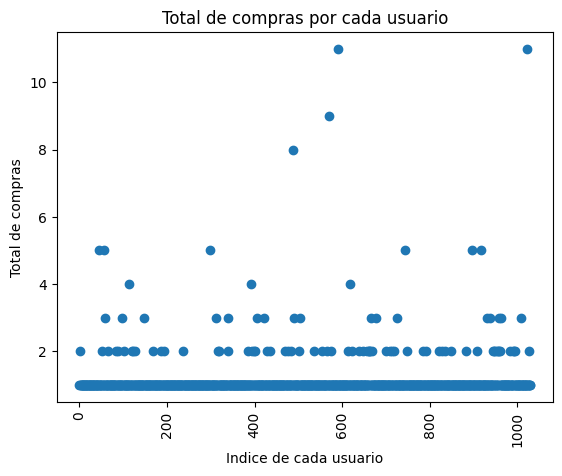

In [34]:
# Agrupo total de ordenes por usuario
ordersByUsers = (orders.groupby("visitorId", as_index=False)
                .agg({"transactionId": pd.Series.nunique,
                    "revenue": "sum"}))
ordersByUsers.columns = ["visitorId", "orders", "costo"]

print(f"Número total de usuarios: {len(ordersByUsers)}")

x_values = pd.Series(range(0,len(ordersByUsers)))
plt.scatter(x_values, ordersByUsers['orders'])
plt.title("Total de compras por cada usuario")
plt.xlabel("Indice de cada usuario")
plt.ylabel("Total de compras")
plt.xticks(rotation=90)

### Comentario:
En su gran mayoría los usuarios comprar una vez. Aunque vemos un número importante de usuarios que compran 2 veces.

### 6. Calcula los percentiles

In [37]:
print(np.percentile(ordersByUsers["orders"], [95, 99]))

[2. 4.]


### Comentario:
Un 5% de los usuarios compra más de 2 artículos. Todos estos usuarios podrían ser tratados como valores atípicos para entender mejor la tendencia entre grupos.

### 7. Gráfico de dispersion de los precios de los pedidos

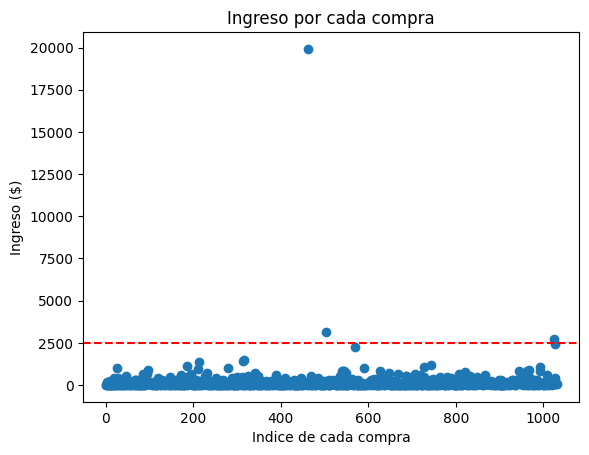

In [38]:
x_values = range(0, len(ordersByUsers['costo']))
plt.scatter(x_values, ordersByUsers['costo'])
plt.axhline(y=2500, color='red', linestyle='--')
plt.title("Ingreso por cada compra")
plt.xlabel("Indice de cada compra")
plt.ylabel("Ingreso ($)")
plt.show()

### Comentario:
A simple vista podríamos pensar que el dataset solo tiene 3 datos atípicos de acuerdo al valor total de compra por usuario. Estos valores están por encima de los 2500$.

### 8. Calcula los percentiles

[ 510.35 1047.24]


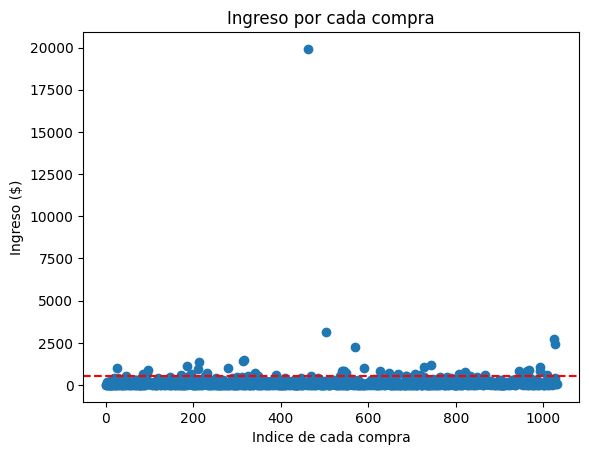

In [39]:
print(np.percentile(ordersByUsers["costo"], [95, 99]))
# 7. Gráfico de dispersion de los precios de los pedidos
x_values = range(0, len(ordersByUsers['costo']))
plt.scatter(x_values, ordersByUsers['costo'])
plt.axhline(y=511, color='red', linestyle='--')
plt.title("Ingreso por cada compra")
plt.xlabel("Indice de cada compra")
plt.ylabel("Ingreso ($)")
plt.show()

### Comentario:
Al hacer el análisis de percentiles advertimos que los usuarios con compras superiores a los 510.35$ podrían ser tratados como valores atípicos. Al graficar la línea roja intermitente podemos ver que se trata de pocos casos.

### 9. Comparo la conversion mediante estadistico z

In [26]:
cumulativeData.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 62 entries, 0 to 61
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        62 non-null     object 
 1   group       62 non-null     object 
 2   orders      62 non-null     int64  
 3   buyers      62 non-null     int64  
 4   revenue     62 non-null     float64
 5   visitors    62 non-null     int64  
 6   conversion  62 non-null     float64
dtypes: float64(2), int64(3), object(2)
memory usage: 3.9+ KB


In [41]:
# Calculo la proporción para cada grupo
# La proporción es la relación entre total usuarios compradores y total visitantes
# Agrupo valores mediante groupby
valores = cumulativeData.groupby("group").agg(
    {"buyers": "sum",
    "revenue": "sum",
    "visitors": "sum"}
).reset_index()
valores.columns = ["group", "compradores", "ingresos", "visitas"]
valores["conversion"] = valores["compradores"]/valores["visitas"]
print(valores)
valores.info()

  group  compradores   ingresos  visitas  conversion
0     A         8381   993927.1   305673    0.027418
1     B         9717  1416949.0   307092    0.031642
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   group        2 non-null      object 
 1   compradores  2 non-null      int64  
 2   ingresos     2 non-null      float64
 3   visitas      2 non-null      int64  
 4   conversion   2 non-null      float64
dtypes: float64(2), int64(2), object(1)
memory usage: 208.0+ bytes


In [42]:
# proporcion de éxito grupoA y grupoB
ca_compradores = valores[valores["group"]=="A"]["compradores"].iloc[0]
cb_compradores = valores[valores["group"]=="B"]["compradores"].iloc[0]
ca_visitas = valores[valores["group"]=="A"]["visitas"].iloc[0]
cb_visitas = valores[valores["group"]=="B"]["visitas"].iloc[0]
ca_conversion = valores[valores["group"]=="A"]["conversion"].iloc[0]
cb_conversion = valores[valores["group"]=="B"]["conversion"].iloc[0]
# Proporción combinada
p_combined = (ca_compradores + cb_compradores) / (ca_visitas + cb_visitas)

# DIFERENCIA OBSERVADA
difference = ca_conversion - cb_conversion

# calculamos el estadístico z
ca_visitas = valores["visitas"].iloc[0]
cb_visitas = valores["visitas"].iloc[1]
z_value = difference / mth.sqrt(p_combined * (1 - p_combined) * (1/ca_visitas + 1/cb_visitas))

print(f"Z-estadístico: {z_value}")


Z-estadístico: -9.76473284248493


Tenemos un z estadístico negativo porque la conversión del grupó B es mayor a la del grupo A.

In [43]:
# establezco la distribucion normal
distr = st.norm(0,1)
# escribe tu código aquí
alpha = 0.05 
p_value = (1-distr.cdf(abs(z_value)))*2# escribe tu código aquí
print('p-value: ', p_value)

if (p_value < alpha):# escribe tu código aquí
    print("Rechazamos la hipótesis nula: hay una diferencia significativa entre las proporciones")
else:
    print("No rechazamos la hipótesis nula: no hay razón para pensar que las proporciones son diferentes")

p-value:  0.0
Rechazamos la hipótesis nula: hay una diferencia significativa entre las proporciones


### Comentario:
El grupo B presentó una tasa de conversión de 0.031 mientras que el grupo A una de 0.027. Esta diferencia es estadísticamente significativa.

### 10. Diferencia estadística en el tamaño promedio del pedido

Grupo A - p-value: 0.19799739122390747
Grupo B - p-value: 0.0114495512
Rechazar la hipótesis nula: la muestra presenta distribución normal
No se pudo rechazar la hipótesis nula: la muestra NO presenta distribución normal


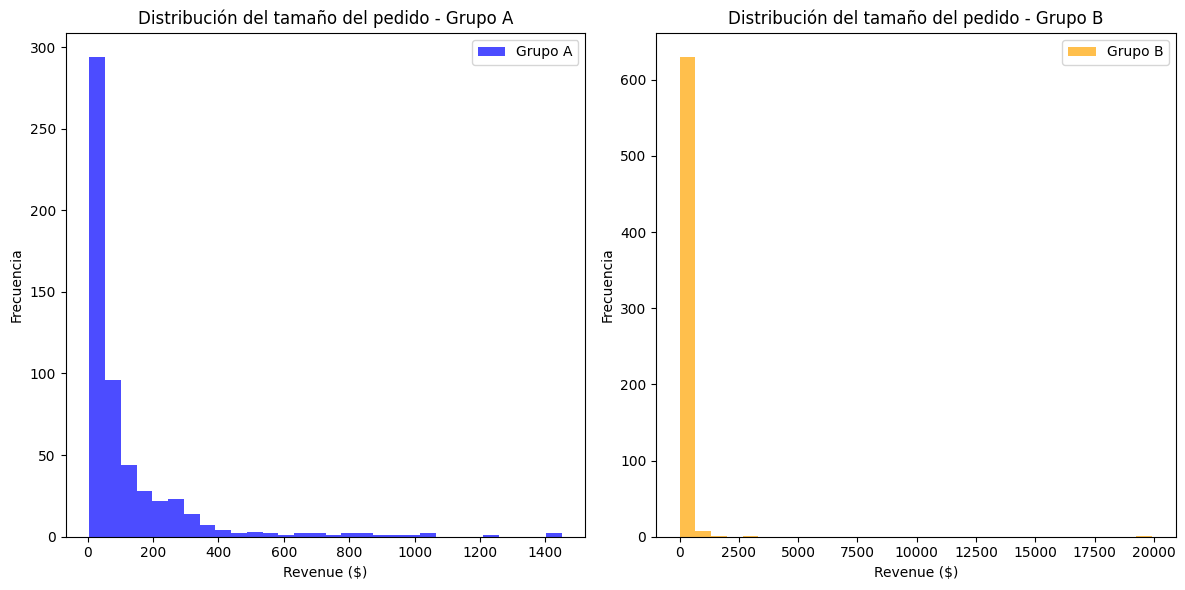

In [44]:
# 1. Verifico la normalidad
ordersA_revenue = cumulativeData[cumulativeData["group"]=="A"]["revenue"]
ordersB_revenue = cumulativeData[cumulativeData["group"]=="B"]["revenue"]

stat_a, p_a = st.shapiro(ordersA_revenue)
stat_b, p_b = st.shapiro(ordersB_revenue)

print(f"Grupo A - p-value: {p_a}")
print(f"Grupo B - p-value: {p_b:.10f}")

if (p_a < alpha):# escribe tu código aquí
    print("No se pudo rechazar la hipótesis nula: la muestra NO presenta distribución normal")
else:
    print("Rechazar la hipótesis nula: la muestra presenta distribución normal")

if (p_b < alpha):# escribe tu código aquí
    print("No se pudo rechazar la hipótesis nula: la muestra NO presenta distribución normal")
else:
    print("Rechazar la hipótesis nula: la muestra presenta distribución normal")

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.hist(orders[orders["group"] == "A"]["revenue"], bins=30, alpha=0.7, color='blue', label='Grupo A')
plt.title("Distribución del tamaño del pedido - Grupo A")
plt.xlabel("Revenue ($)")
plt.ylabel("Frecuencia")
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(orders[orders["group"] == "B"]["revenue"], bins=30, alpha=0.7, color='orange', label='Grupo B')
plt.title("Distribución del tamaño del pedido - Grupo B")
plt.xlabel("Revenue ($)")
plt.ylabel("Frecuencia")
plt.legend()

plt.tight_layout()
plt.show()

### Comentario:
Mediante la prueba Shapiro y la gráfica comprobamos que no hay distribución normal. Sin embargo la cola del grupo A es más suabe que la del grupo B. Esto se debe a un valor a típico que presenta el grupo B no permite visualizar muy bien la distribución de los datos. 

In [60]:
# Como las muestras no siguen distribución normal, compararemos sus distribuciones mediante test Mann Whitney
# Primero haré una prueba bilateral
alpha = 0.05
results = st.mannwhitneyu(ordersA_revenue, ordersB_revenue)# escribe tu código aquí
print('valor p: ', results.pvalue)# escribe tu código aquí
if (results.pvalue < alpha):# escribe tu código aquí
    print("Hipótesis nula rechazada:  SÍ existe diferencia significativa entre las distribuciones")
else:
    print("No se rechazó la hipótesis nula: no existen diferencias significativas entre las distribuciones de los dos grupos comparados")

valor p:  0.6915246773264736
No se rechazó la hipótesis nula: no existen diferencias significativas entre las distribuciones de los dos grupos comparados


### Comentario:
Aunque sí hay diferencias en la conversión, el tamaño de la compra es estadísticamente igual en ambos grupos. Es importante hacer nuevamente la evaluación quitando los datos atípicos de valores de compra, como el del grupo B que supera los 17500. 

### # 11. Comparo la conversion mediante estadistico z con datos filtrados

In [57]:
order_visit_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1020 entries, 0 to 1019
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   transactionId  1020 non-null   int64  
 1   visitorId      1020 non-null   int64  
 2   date           1020 non-null   object 
 3   revenue        1020 non-null   float64
 4   group          1020 non-null   object 
 5   visits         1020 non-null   int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 55.8+ KB


In [61]:
# Como la distribución de la conversion diaria es normal, eliminaré a los usuarios atípicos que realizan más de 2 compras
usersWithManyOrders = ordersByUsers[ordersByUsers['orders'] > 2]['visitorId']
# También filtraré ese 1% de tamaños de compra superiores a 1048$
usersWithExpensiveOrders = ordersByUsers[ordersByUsers['costo'] > 511]['visitorId']
abnormalUsers = pd.concat([usersWithManyOrders, usersWithExpensiveOrders], axis = 0).drop_duplicates().sort_values()
order_filtered = orders[~orders["visitorId"].isin(abnormalUsers)]
ordersAggregated_filtered = datesGroups.apply(lambda x: order_filtered[np.logical_and(order_filtered['date'] <= x['date'], order_filtered['group'] == x['group'])].agg({'date' : 'max', 'group' : 'max', 'transactionId' : pd.Series.nunique, 'visitorId' : pd.Series.nunique, 'revenue' : 'sum'}), axis=1).sort_values(by=['date','group'])
order_visit_filtered = ordersAggregated_filtered.merge(visitsAggregated, on = ["date", "group"], how = "right")
print(order_visit_filtered.info())

<class 'pandas.core.frame.DataFrame'>
Int64Index: 62 entries, 0 to 61
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           62 non-null     object 
 1   group          62 non-null     object 
 2   transactionId  62 non-null     int64  
 3   visitorId      62 non-null     int64  
 4   revenue        62 non-null     float64
 5   visits         62 non-null     int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 3.4+ KB
None


In [62]:
# Nueva agruácion con valores filtrados
valores_filtrados = order_visit_filtered.groupby("group").agg(
    {"visitorId": "count",
    "revenue": "sum",
    "visits": "sum"}
).reset_index()
valores_filtrados.columns = ["group", "compradores", "ingresos", "visitas"]
valores_filtrados["conversion"] = valores_filtrados["compradores"]/valores_filtrados["visitas"]
print(valores_filtrados)
valores_filtrados.info()

  group  compradores  ingresos  visitas  conversion
0     A           31  647403.8   305673    0.000101
1     B           31  770894.5   307092    0.000101
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   group        2 non-null      object 
 1   compradores  2 non-null      int64  
 2   ingresos     2 non-null      float64
 3   visitas      2 non-null      int64  
 4   conversion   2 non-null      float64
dtypes: float64(2), int64(2), object(1)
memory usage: 208.0+ bytes


Resulta interesante que al eliminar los usuarios atípicos, la tasa de conversión bajó muchísimo.

In [63]:
# proporcion de éxito grupoA
ca_compradores = valores[valores["group"]=="A"]["compradores"].iloc[0]
cb_compradores = valores[valores["group"]=="B"]["compradores"].iloc[0]
ca_visitas = valores[valores["group"]=="A"]["visitas"].iloc[0]
cb_visitas = valores[valores["group"]=="B"]["visitas"].iloc[0]
ca_conversion = valores[valores["group"]=="A"]["conversion"].iloc[0]
cb_conversion = valores[valores["group"]=="B"]["conversion"].iloc[0]
# Proporción combinada
p_combined = (ca_compradores + cb_compradores) / (ca_visitas + cb_visitas)

# DIFERENCIA OBSERVADA
difference = ca_conversion - cb_conversion

# calculamos el estadístico z
ca_visitas = valores["visitas"].iloc[0]
cb_visitas = valores["visitas"].iloc[1]
z_value = difference / mth.sqrt(p_combined * (1 - p_combined) * (1/ca_visitas + 1/cb_visitas))

print(f"Z-estadístico: {z_value}")

Z-estadístico: -9.76473284248493


In [68]:
# establezco la distribucion normal
distr = st.norm(0,1)
# escribe tu código aquí
alpha = 0.05 
p_value = (1-distr.cdf(abs(z_value)))*2# escribe tu código aquí
print(f'p-value: {p_value:.7f}')

if (p_value < alpha):# escribe tu código aquí
    print("Rechazar la hipótesis nula: hay una diferencia significativa entre las proporciones")
else:

    print("No se pudo rechazar la hipótesis nula: no hay razón para pensar que las proporciones son diferentes")

p-value: 0.0000000
Rechazar la hipótesis nula: hay una diferencia significativa entre las proporciones


### Comentario:
Cuando filtramos los datos, la diferencia entre las tasas de conversión o proporciones de conversión sigue siendo estadísticamente diferente. 

### 12. Significancia estadística entre el tamaño promedio de la compra de los grupos con datos filtrados

Grupo A - p-value: 0.24757453799247742
Grupo B - p-value: 0.3281541168689728
No podemos rechazar la hipótesis nula: la muestra presenta distribución normal
No podemos rechazar la hipótesis nula: la muestra presenta distribución normal


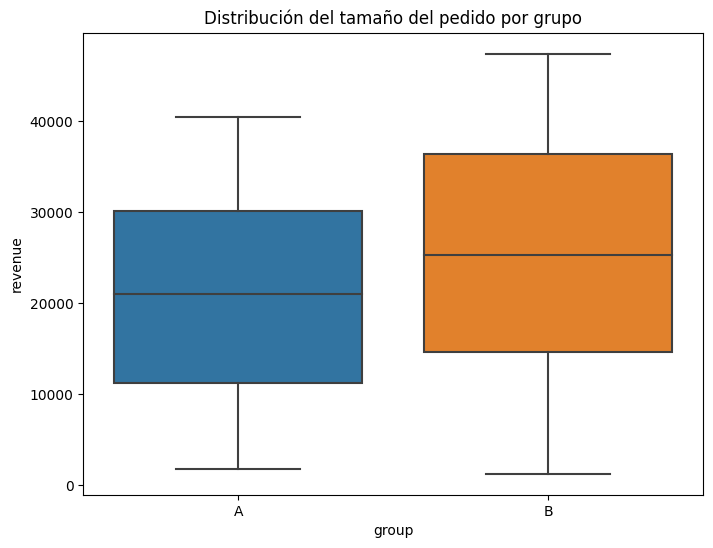

In [65]:
# 1. Verifico la normalidad
ordersA_revenue = order_visit_filtered[order_visit_filtered["group"]=="A"]["revenue"]
ordersB_revenue = order_visit_filtered[order_visit_filtered["group"]=="B"]["revenue"]

stat_a, p_a = st.shapiro(ordersA_revenue)
stat_b, p_b = st.shapiro(ordersB_revenue)

print(f"Grupo A - p-value: {p_a}")
print(f"Grupo B - p-value: {p_b}")

if (p_a < alpha):# escribe tu código aquí
    print("Rechazamos la hipótesis nula: la muestra NO presenta distribución normal")
else:
    print("No podemos rechazar la hipótesis nula: la muestra presenta distribución normal")

if (p_b < alpha):# escribe tu código aquí
    print("Rechazamos la hipótesis nula: la muestra NO presenta distribución normal")
else:
    print("No podemos rechazar la hipótesis nula: la muestra presenta distribución normal")

plt.figure(figsize=(8, 6))
sns.boxplot(data=order_visit_filtered, x="group", y="revenue")
plt.title("Distribución del tamaño del pedido por grupo")
plt.show()

### Comentario:
Con los datos filtrados, las muestras no alcanzaron la normalidad, aunque ahora tienen una mejor visualización. Efectivamente ambas muestras presentan un sesgo hacia la derecha.

In [66]:
# Como las muestras no siguen distribución normal, compararemos sus distribuciones mediante test Mann Whitney
alpha = 0.05# escribe tu código aquí
results = st.mannwhitneyu(ordersA_revenue, ordersB_revenue)# escribe tu código aquí
print('valor p: ', results.pvalue)# escribe tu código aquí
if (results.pvalue < alpha):# escribe tu código aquí
    print("Hipótesis nula rechazada: no podemos sacar conclusiones sobre la diferencia")
else:
    print("No se rechazó la hipótesis nula: no existen diferencias significativas entre las distribuciones de los dos grupos comparados")


valor p:  0.2425964293442916
No se rechazó la hipótesis nula: no existen diferencias significativas entre las distribuciones de los dos grupos comparados


### Comentario:
Los grupos presentan un comportamiento similar. Esto lo podemos verificar con el diagrama de cajas. El 50% de las compras tienen un tamaño de 50 porciento y el 75 porciento supera sutilmente los 100. Los valores atípicos están por arriba de los 250 (para ambos grupos. 

## CONCLUSIONES GENERALES:
A través del análisis pudimos observar que hay diferencias estadísticas entre la tasa de conversión, siendo ás alta la del tratamiento B (p value  < 5%) incluso eliminando los datos atípicos. El gráfico de conversión acumulada pareciera indicar una estabilidad, sin embargo, los gráficos asociados al tamaño promedio de la compra (acumulado) nos indican crecimiento, y aún no se han estabilizado. En cuanto al análisis estadístico, el tamaño de la prueba no parece presentar diferencias estadísticas. Considero que la prueba puede tomar un tiempo adicional para buscar la estabilidad en las tasas de conversión y de esta forma adoptar la estrategia que represente mayores compradores e ingresos.